In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ML_Linear_Regression.Linear_Reg_Multi_input import validation_x
from fontTools.misc.cython import returns

ModuleNotFoundError: No module named 'ML_Linear_Regression.Linear_Reg_Multi_input'

In [2]:
root_dir = os.getcwd()
data_dir = os.path.join(root_dir, "data")
dataset_path = os.path.join(data_dir, "Housing.csv")

In [3]:
df = pd.read_csv(dataset_path)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [5]:
DF = df[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'price']]
DF.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,13300000
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,12250000
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,12250000
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,12215000
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,11410000


In [6]:
Num_colums = DF.select_dtypes(include= "number").columns
Num_colums

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price'], dtype='object')

In [7]:
Cat_colums = DF.select_dtypes(include= "object").columns
Cat_colums

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
Mean = DF[Num_colums].mean()
Std = DF[Num_colums].std()

In [9]:
DF[Num_colums] = (DF[Num_colums] - Mean) / Std
DF.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,1.045766,1.402131,1.420507,1.376952,yes,no,no,no,yes,1.516299,yes,furnished,4.562174
1,1.755397,1.402131,5.400847,2.529700,yes,no,no,no,yes,2.676950,no,furnished,4.000809
2,2.216196,0.047235,1.420507,0.224204,yes,no,yes,no,no,1.516299,yes,semi-furnished,4.000809
3,1.082630,1.402131,1.420507,0.224204,yes,no,yes,no,yes,2.676950,yes,furnished,3.982096
4,1.045766,1.402131,-0.569663,0.224204,yes,yes,yes,no,yes,1.516299,no,furnished,3.551716


In [10]:
DF[Cat_colums] = DF[Cat_colums].apply(
    lambda col: pd.Categorical(col).codes
)
DF.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,1.045766,1.402131,1.420507,1.376952,1,0,0,0,1,1.516299,1,0,4.562174
1,1.755397,1.402131,5.400847,2.529700,1,0,0,0,1,2.676950,0,0,4.000809
2,2.216196,0.047235,1.420507,0.224204,1,0,1,0,0,1.516299,1,1,4.000809
3,1.082630,1.402131,1.420507,0.224204,1,0,1,0,1,2.676950,1,0,3.982096
4,1.045766,1.402131,-0.569663,0.224204,1,1,1,0,1,1.516299,0,0,3.551716


In [11]:
seed = 48
np.random.seed(seed)

def split_dataset(dataset, training_ratio = 0.6, val_ratio = 0.2):
    no_of_example = len(dataset)
    random_indices = np.random.permutation(no_of_example)

    train_size = int(no_of_example * training_ratio)
    val_size = int(no_of_example * val_ratio)

    train_indices = random_indices[: train_size]
    val_indices = random_indices[train_size : train_size + val_size]
    test_indices = random_indices[train_size + val_size :]

    train_ds = dataset.iloc[train_indices]
    val_ds = dataset.iloc[val_indices]
    test_ds = dataset.iloc[test_indices]

    train_x = train_ds.iloc[: , : -1]
    train_y = train_ds.iloc[: , -1]

    val_x = val_ds.iloc[: , : -1]
    val_y = val_ds.iloc[: , -1]

    test_x = test_ds.iloc[: , : -1]
    test_y = test_ds.iloc[: , -1]

    return train_x, train_y, val_x, val_y, test_x, test_y
train_x, train_y, val_x, val_y, test_x, test_y = split_dataset(DF)

In [12]:
print(len(train_x))
print(len(val_x))
print(len(test_x))

327
109
109


In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [14]:
Df = df[["area", "price"]]
Df.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [15]:
def normalize(col):
    mean = col.mean()
    std = col.std()
    return (col - mean) / std
Normalized_Df = Df.agg(normalize)
Normalized_Df.head()

,area,price
0,1.045766,4.562174
1,1.755397,4.000809
2,2.216196,4.000809
3,1.082630,3.982096
4,1.045766,3.551716


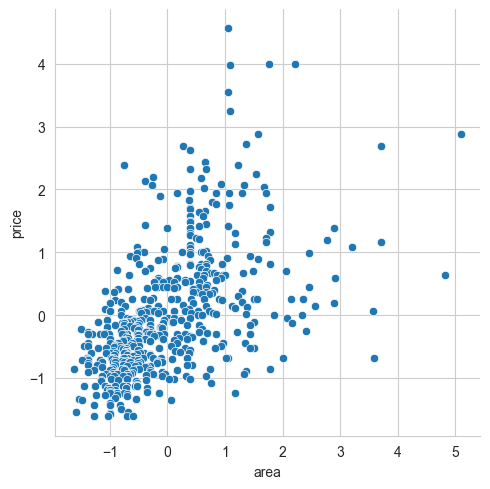

In [16]:
sns.relplot(
    data = Normalized_Df,
    x = "area",
    y = "price"
)

In [17]:
def get_house_price(X, w, b):
    y_pred = w * X + b
    return y_pred

In [18]:
# seed = 49
# np.random.seed(seed)
w = np.random.randint(10, 150)
b = np.random.randint(10, 150)
print(w, b)

129 121


In [56]:
Normalized_Df.shape

(545, 4)

In [55]:
Normalized_Df["predicted_price"] = get_house_price(Normalized_Df["area"], w, b)
Normalized_Df.head(20)

,area,price,predicted_price,Predicted_price_learned
0,1.045766,4.562174,165.217272,0.560528
1,1.755397,4.000809,246.115241,0.940888
2,2.216196,4.000809,298.646389,1.187875
3,1.082630,3.982096,169.419764,0.580287
4,1.045766,3.551716,165.217272,0.560528
5,1.082630,3.252321,169.419764,0.580287
6,1.580293,2.878078,226.153405,0.847033
7,5.091586,2.878078,626.440755,2.729076
8,1.359109,2.728380,200.938453,0.728479
9,0.276230,2.690956,77.490255,0.148059


In [20]:
Dis = Normalized_Df.melt(
    value_vars = ["price", "predicted_price"],
    var_name = "Type",
    value_name = "Price"
)
Dis["Price"] = Dis.groupby("Type")["Price"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
Dis.tail()

,Type,Price
1085,predicted_price,0.092784
1086,predicted_price,0.051546
1087,predicted_price,0.135395
1088,predicted_price,0.086598
1089,predicted_price,0.151203


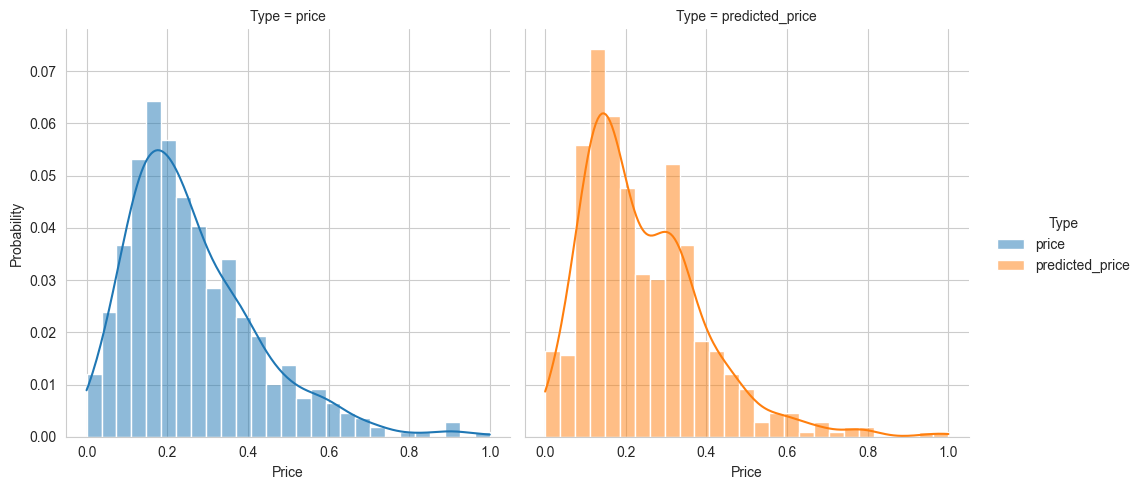

In [21]:
sns.displot(
    data= Dis,
    x= "Price",
    hue = "Type",
    kind= "hist",
    col = "Type",
    kde = True,
    fill = True,
    stat= "probability"
)

In [22]:
def cost_function(X, y_true, w, b):
 y_pred = get_house_price(X, w, b)
 mse = np.mean((y_true - y_pred) ** 2) / 2
 return mse

X = Normalized_Df["area"]
y_true = Normalized_Df["price"]
loss = cost_function(X, y_true, w, b)
print(loss)

15557.215321582891


In [23]:
loss1 = cost_function(X, y_true, w = 45, b = 15)
print(loss1)
loss2 = cost_function(X, y_true, w = 40, b = 12)
print(loss2)
loss3 = cost_function(X, y_true, w = 35, b = 9)
print(loss3)

1099.5656605052338
849.6306380841633
633.6497441034593


In [24]:
def compute_gradient(X, y_true, w, b):
    m = len(X)
    y_pred = get_house_price(X, w, b)
    dw = np.sum((y_pred - y_true) * X) / m
    db = np.sum(y_pred - y_true) / m
    return dw , db

In [25]:
print(w, b)
print(loss)

129 121
15557.215321582891


In [26]:
dw, db = compute_gradient(X, y_true, w, b)
print(dw, db)

128.22828888788388 121.0


In [62]:
learning_rate = 0.1
w = w - learning_rate * dw
b = b - learning_rate * db

In [63]:
loss = cost_function(X, y_true, w, b)
print(loss)

0.35569956316830836


In [64]:
for epoch in range(10000):
    loss = cost_function(X, y_true, w, b)
    dw, db = compute_gradient(X, y_true, w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 1000 == 0:
        print(loss)

0.35569956316830836
0.3556995631683083
0.3556995631683083
0.3556995631683083
0.3556995631683083
0.3556995631683083
0.3556995631683083
0.3556995631683083
0.3556995631683083
0.3556995631683083


In [73]:
if epoch % 1000 == 0:
    print("loss:", loss)
    print("dw:", dw)
    print("db:", db)
    print("w:", w)
    print("b:", b)

In [30]:
for epoch in range(10):
    dw, db = compute_gradient(X, y_true, w, b)
    print(dw, db)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    loss = cost_function(X, y_true, w, b)
    print(loss)

1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836
1.029961029817393e-15 0.0
0.35569956316830836


In [31]:
print(w, b)

0.5359973457780811 3.029113394921135e-16


In [32]:
Normalized_Df["Predicted_price_learned"] = get_house_price(Normalized_Df["area"], w, b)
Normalized_Df.head()

,area,price,predicted_price,Predicted_price_learned
0,1.045766,4.562174,255.903756,0.560528
1,1.755397,4.000809,347.446194,0.940888
2,2.216196,4.000809,406.889335,1.187875
3,1.082630,3.982096,260.659207,0.580287
4,1.045766,3.551716,255.903756,0.560528


In [33]:
dis = Normalized_Df.melt(
    value_vars = ["price", "Predicted_price_learned"],
    var_name = "Type",
    value_name = "Price"
)
dis["Predicted Price"] = dis.groupby("Type")["Price"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
dis.head()

,Type,Price,Predicted Price
0,price,4.562174,1.000000
1,price,4.000809,0.909091
2,price,4.000809,0.909091
3,price,3.982096,0.906061
4,price,3.551716,0.836364


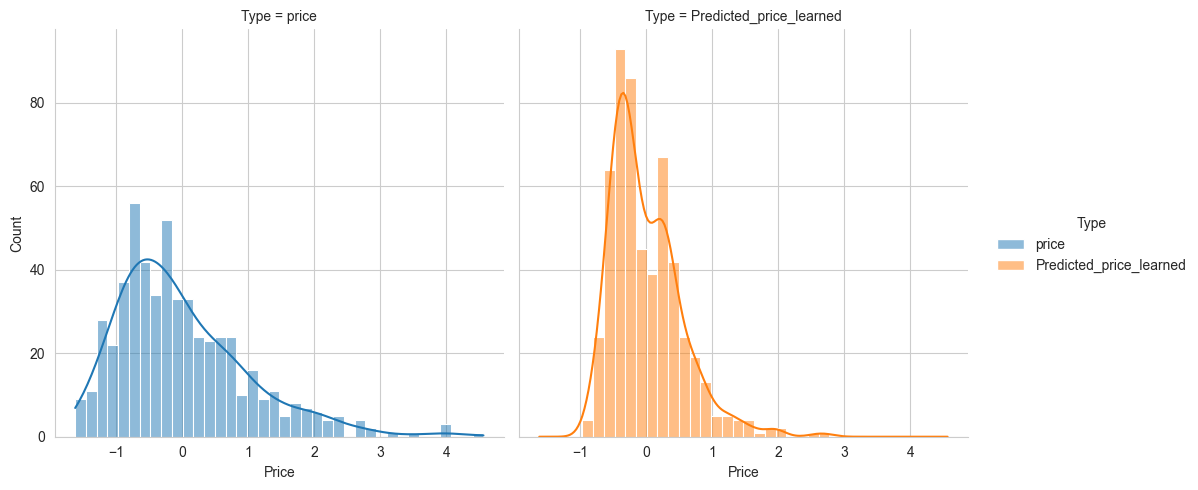

In [34]:
sns.displot(
    data= dis,
    x = "Price",
    hue = "Type",
    col = "Type",
    kde = True,
    kind = "hist",
    fill = True
)

In [35]:
Root_dir = os.getcwd()
Data_dir = os.path.join(Root_dir, "data")
Dataset_path = os.path.join(Data_dir, "company_sales_data.csv")
company_data = pd.read_csv(Dataset_path)
company_data.head()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600


In [36]:
Company_data = company_data[["total_units", "total_profit"]]
Company_data.head()

,total_units,total_profit
0,21100,211000
1,18330,183300
2,22470,224700
3,22270,222700
4,20960,209600


In [37]:
def standardization(col):
    Mean = col.mean()
    Std = col.std()
    return (col - Mean) / Std
Company_data_normalized = Company_data.agg(standardization)
Company_data_normalized.head()

,total_units,total_profit
0,-0.702487,-0.702487
1,-1.097391,-1.097391
2,-0.507173,-0.507173
3,-0.535686,-0.535686
4,-0.722446,-0.722446


In [38]:
company_data.head()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600


In [39]:
Mod_company_data = company_data[["total_units", "total_profit"]]
Mod_company_data.head()

,total_units,total_profit
0,21100,211000
1,18330,183300
2,22470,224700
3,22270,222700
4,20960,209600


In [40]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())
Normalized_company_data = Mod_company_data.agg(normalize)
Normalized_company_data.head()

,total_units,total_profit
0,0.120697,0.120697
1,0.000000,0.000000
2,0.180392,0.180392
3,0.171678,0.171678
4,0.114597,0.114597


In [41]:
Company_data_normalized.head()

,total_units,total_profit
0,-0.702487,-0.702487
1,-1.097391,-1.097391
2,-0.507173,-0.507173
3,-0.535686,-0.535686
4,-0.722446,-0.722446


In [42]:
def expected_profit(x, w, b):
    y_pred = x * w + b
    return y_pred

In [43]:
w = np.random.randint(20, 200)
b = np.random.randint(20, 200)

In [44]:
Normalized_company_data["predicted_profit"] = expected_profit(Normalized_company_data["total_units"], w, b)
Normalized_company_data.head()

,total_units,total_profit,predicted_profit
0,0.120697,0.120697,59.759477
1,0.000000,0.000000,46.000000
2,0.180392,0.180392,66.564706
3,0.171678,0.171678,65.571242
4,0.114597,0.114597,59.064052


In [45]:
Normalized_company_data = Normalized_company_data.drop(columns = ["predicted_price"])
Normalized_company_data.head()

KeyError: "['predicted_price'] not found in axis"

In [143]:
Displot = Normalized_company_data.melt(
    value_vars = ["total_profit", "predicted_profit"],
    var_name = "Type",
    value_name = "Profit"
)
Displot["Profit"] = Displot.groupby("Type")["Profit"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

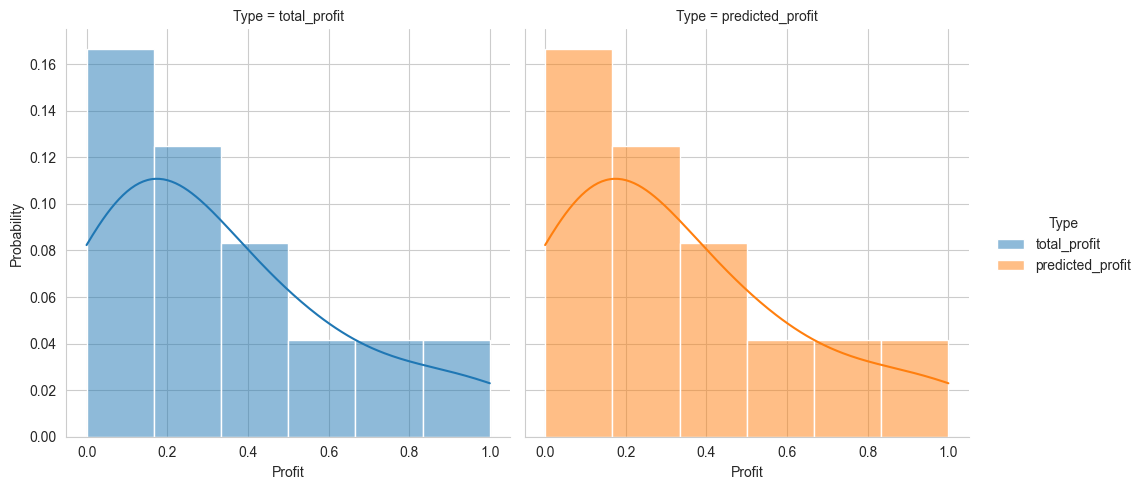

In [145]:
sns.displot(
    data= Displot,
    x = "Profit",
    hue = "Type",
    col = "Type",
    kde = True,
    kind = "hist",
    stat = "probability",
    fill = True
)

In [2]:
Root = os.getcwd()
Data_directory = os.path.join(Root, "data")
Data_set_path = os.path.join(Data_directory, "Housing.csv")
Housing_dataset = pd.read_csv(Data_set_path)
Housing_dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
Housing_dataset.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [4]:
Housing_dataset = Housing_dataset[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'price']]
Housing_dataset.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,13300000
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,12250000
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,12250000
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,12215000
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,11410000


In [5]:
Housing_dataset_numeric = Housing_dataset.select_dtypes(include= "number").columns

In [6]:
Housing_dataset_cat = Housing_dataset.select_dtypes(include= "object").columns

In [7]:
def Standardize(col):
    Mean = col.mean()
    Std = col.std()
    return (col - Mean) / Std
Housing_dataset[Housing_dataset_numeric] = Housing_dataset[Housing_dataset_numeric].agg(Standardize)
Housing_dataset.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,1.045766,1.402131,1.420507,1.376952,yes,no,no,no,yes,1.516299,yes,furnished,4.562174
1,1.755397,1.402131,5.400847,2.529700,yes,no,no,no,yes,2.676950,no,furnished,4.000809
2,2.216196,0.047235,1.420507,0.224204,yes,no,yes,no,no,1.516299,yes,semi-furnished,4.000809
3,1.082630,1.402131,1.420507,0.224204,yes,no,yes,no,yes,2.676950,yes,furnished,3.982096
4,1.045766,1.402131,-0.569663,0.224204,yes,yes,yes,no,yes,1.516299,no,furnished,3.551716


In [8]:
Housing_dataset[Housing_dataset_cat] = Housing_dataset[Housing_dataset_cat].apply(
    lambda col: pd.Categorical(col).codes
)
Housing_dataset.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,1.045766,1.402131,1.420507,1.376952,1,0,0,0,1,1.516299,1,0,4.562174
1,1.755397,1.402131,5.400847,2.529700,1,0,0,0,1,2.676950,0,0,4.000809
2,2.216196,0.047235,1.420507,0.224204,1,0,1,0,0,1.516299,1,1,4.000809
3,1.082630,1.402131,1.420507,0.224204,1,0,1,0,1,2.676950,1,0,3.982096
4,1.045766,1.402131,-0.569663,0.224204,1,1,1,0,1,1.516299,0,0,3.551716


In [98]:
seed = 30
np.random.seed(seed)

def spliting_dataset(dataset, training_ratio = 0.6, validation_ratio = 0.2):
    no_of_example = len(dataset)
    random_indices = np.random.permutation(no_of_example)

    train_size = int(no_of_example * training_ratio)
    validation_size = int(no_of_example * validation_ratio)

    training_indices = random_indices[: train_size]
    validation_indices = random_indices[train_size: train_size + validation_size]
    test_indices = random_indices[train_size + validation_size : ]

    training_dataset = dataset.iloc[training_indices]
    validation_dataset = dataset.iloc[validation_indices]
    test_dataset = dataset.iloc[test_indices]

    train_x = training_dataset.iloc[: , : -1]
    train_y = training_dataset.iloc[: , -1]

    validation_x = validation_dataset.iloc[: , : -1]
    validation_y = validation_dataset.iloc[: , -1]

    test_x = test_dataset.iloc[: , : -1]
    test_y = test_dataset.iloc[: , -1]

    return train_x, train_y, validation_x, validation_y, test_x, test_y
train_x, train_y, validation_x, validation_y, test_x, test_y = spliting_dataset(Housing_dataset)

In [99]:
print(len(train_x))
print(len(validation_x))
print(len(test_x))
print(train_x.shape)
print(validation_x.shape)
print(test_x.shape)

327
109
109
(327, 12)
(109, 12)
(109, 12)


In [100]:
print(train_x.columns)
print(validation_x.columns)

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [101]:
"""Housing Price Prediction"""
def get_house_price(x, W, B):
    y_Pred = np.dot(x, W) + B
    return y_Pred

In [102]:
W = np.random.randint(low= 100, high= 200, size= train_x.shape[1])
B = np.random.randint(low= 100, high= 200)
print(f"Weight = {W}, Bias = {B}")

Weight = [182 162 190 181 183 127 119 183 131 151 161 143], Bias = 149


In [103]:
print(train_x.shape)

(327, 12)


In [104]:
def Cost_function(x, y_True, W, B):
    y_Pred = get_house_price(x, W, B)
    Mse = np.mean((y_True - y_Pred) ** 2)
    return Mse
Mse = Cost_function(train_x, train_y, W, B)
print(f"MSE = {Mse} (Parameters are not learned yet)")

MSE = 713128.3249844915 (Parameters are not learned yet)


In [105]:
def Compute_Gradient(x, y_True, W, B):
    m = len(y_True)
    y_Pred = get_house_price(x, W, B)
    error = y_Pred - y_True
    dw = (2/m) * np.dot(x.T, error)
    db = (2/m) * np.sum(error)
    return dw, db

In [106]:
lr = 0.0001
W = np.zeros(train_x.shape[1])
B = 0

In [107]:
print(validation_x.shape)
print(train_x.shape)
print(W.shape)

(109, 12)
(327, 12)
(12,)


In [108]:
epochs = 10000
for Epoch in range(epochs):
    """Compute logis"""
    loss = Cost_function(train_x, train_y, W, B)
    validation_loss = Cost_function(validation_x, validation_y, W, B)
    """Compute Gradient"""
    dw, db = Compute_Gradient(train_x, train_y, W, B)
    """Update Parameters"""
    W = W - lr * dw
    B = B - lr * db

    if Epoch % 1000 == 0:
        print(f"epoch {Epoch} / {epochs}: loss = {loss:0.2f} val_loss = {validation_loss:0.2f}")

epoch 0 / 10000: loss = 1.06 val_loss = 0.88
epoch 1000 / 10000: loss = 0.72 val_loss = 0.59
epoch 2000 / 10000: loss = 0.56 val_loss = 0.47
epoch 3000 / 10000: loss = 0.48 val_loss = 0.42
epoch 4000 / 10000: loss = 0.44 val_loss = 0.39
epoch 5000 / 10000: loss = 0.42 val_loss = 0.38
epoch 6000 / 10000: loss = 0.41 val_loss = 0.38
epoch 7000 / 10000: loss = 0.40 val_loss = 0.38
epoch 8000 / 10000: loss = 0.39 val_loss = 0.38
epoch 9000 / 10000: loss = 0.39 val_loss = 0.37


In [109]:
print(W, B)

[ 0.33831301  0.09629384  0.23459507  0.22465845  0.06773791  0.06139576
  0.09775428  0.04404053  0.19363321  0.18238737  0.14159663 -0.15086893] -0.006642386213556012


In [110]:
testloss = Cost_function(test_x, test_y, W, B)
print(testloss)

0.27844679240833614
